In [52]:
# Importing usefull libraries
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

In [53]:
def y_exact(x_eval, epsilon):
    
    def fun(x, y):
        return np.vstack((y[1], (2*(x**2 + 1)*y[1] - 1)/epsilon))
    
    def bc(ya, yb):
        return np.array([ya[0], yb[0]])
    
    x_init = np.linspace(0, 1, 5)  # initial mesh with 5 nodes
    y_init = np.zeros((2, x_init.size))
    
    res_a = solve_bvp(fun, bc, x_init, y_init)
    
    return res_a.sol(x_eval)[0]  # exact solution as a function of x_eval

# Visualize exact solutions and leading order composite solutions

In [54]:
x_eval = np.linspace(0, 1, 2000)  # interval [0, 1] with 2000 points

epsilon1 = 0.1   # small parameter 0.1
epsilon2 = 0.05  # smaller parameter 0.05
epsilon3 = 0.01  # very small parameter 0.01

In [55]:
y_outer = lambda x: 0.5 * np.arctan(x)  # leading-order outer solution

Y_inner = lambda x, epsilon: (np.pi/8) * (1 - np.exp(-4*(1-x)/epsilon))  # leading-order inner solution

y_composite_0 = lambda x, epsilon: y_outer(x) - (np.pi/8) * np.exp(-4*(1-x)/epsilon)  # composite solution

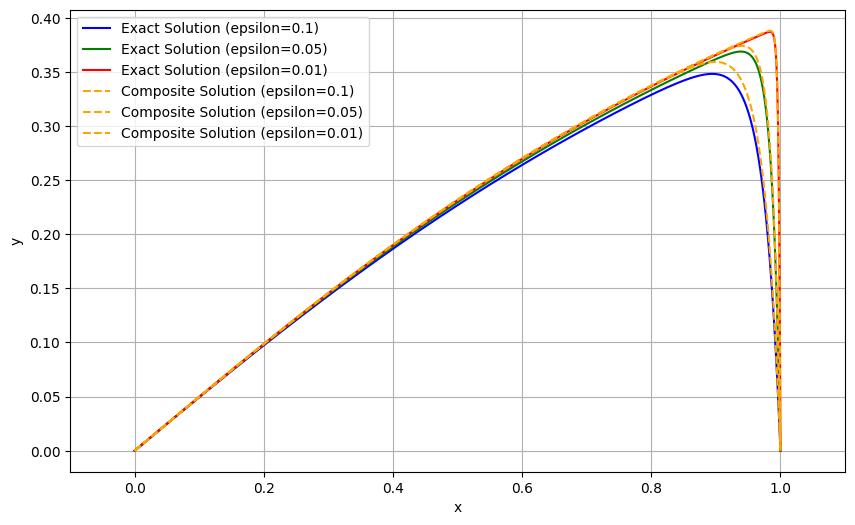

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(x_eval, y_exact(x_eval, epsilon1), label='Exact Solution (epsilon=0.1)', color='blue', linestyle='-')
plt.plot(x_eval, y_exact(x_eval, epsilon2), label='Exact Solution (epsilon=0.05)', color='green', linestyle='-')
plt.plot(x_eval, y_exact(x_eval, epsilon3), label='Exact Solution (epsilon=0.01)', color='red', linestyle='-')
plt.plot(x_eval, y_composite_0(x_eval, epsilon=epsilon1), label='Composite Solution (epsilon=0.1)', color='orange', linestyle='--')
plt.plot(x_eval, y_composite_0(x_eval, epsilon=epsilon2), label='Composite Solution (epsilon=0.05)', color='orange', linestyle='--')
plt.plot(x_eval, y_composite_0(x_eval, epsilon=epsilon3), label='Composite Solution (epsilon=0.01)', color='orange', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.1, 1.1)
plt.legend()
plt.grid()
plt.savefig("images/leading-order.pdf", bbox_inches="tight")
plt.show()

# Visualize O($\varepsilon$) corrected composite solution

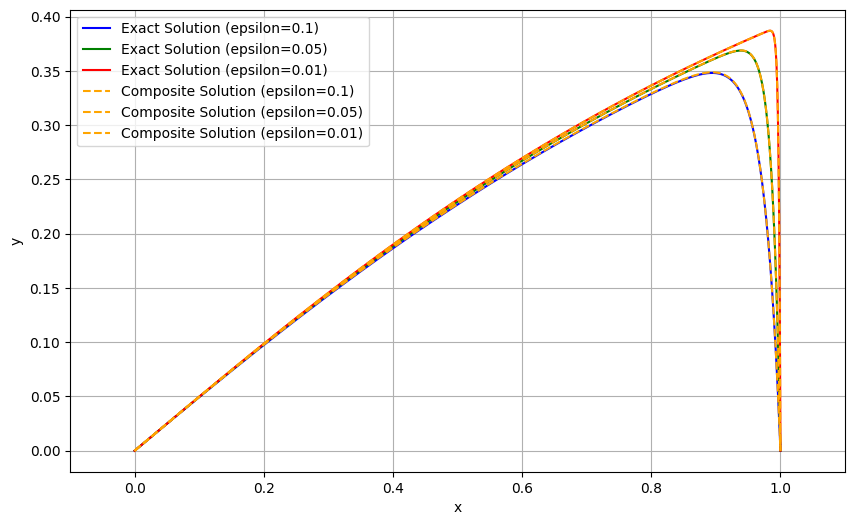

In [57]:
y_composite_1 = lambda x, epsilon: (
    0.5 * np.arctan(x)
    - (np.pi/8) * np.exp(-4*(1-x)/epsilon)
    + (epsilon/8) * (1/(1 + x**2)**2 - 1)
    + epsilon * np.exp(-4*(1-x)/epsilon) * (
        3/32
        - (np.pi/8) * (1-x)/epsilon
        - (np.pi/4) * ((1-x)/epsilon)**2
    )
)

plt.figure(figsize=(10, 6))
plt.plot(x_eval, y_exact(x_eval, epsilon1), label='Exact Solution (epsilon=0.1)', color='blue', linestyle='-')
plt.plot(x_eval, y_exact(x_eval, epsilon2), label='Exact Solution (epsilon=0.05)', color='green', linestyle='-')
plt.plot(x_eval, y_exact(x_eval, epsilon3), label='Exact Solution (epsilon=0.01)', color='red', linestyle='-')
plt.plot(x_eval, y_composite_1(x_eval, epsilon=epsilon1), label='Composite Solution (epsilon=0.1)', color='orange', linestyle='--')
plt.plot(x_eval, y_composite_1(x_eval, epsilon=epsilon2), label='Composite Solution (epsilon=0.05)', color='orange', linestyle='--')
plt.plot(x_eval, y_composite_1(x_eval, epsilon=epsilon3), label='Composite Solution (epsilon=0.01)', color='orange', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.1, 1.1)
plt.legend()
plt.grid()
plt.savefig("images/epsilon-order.pdf", bbox_inches="tight")
plt.show()

# Comparison of the solutions at different orders for $\varepsilon$ = 0.1

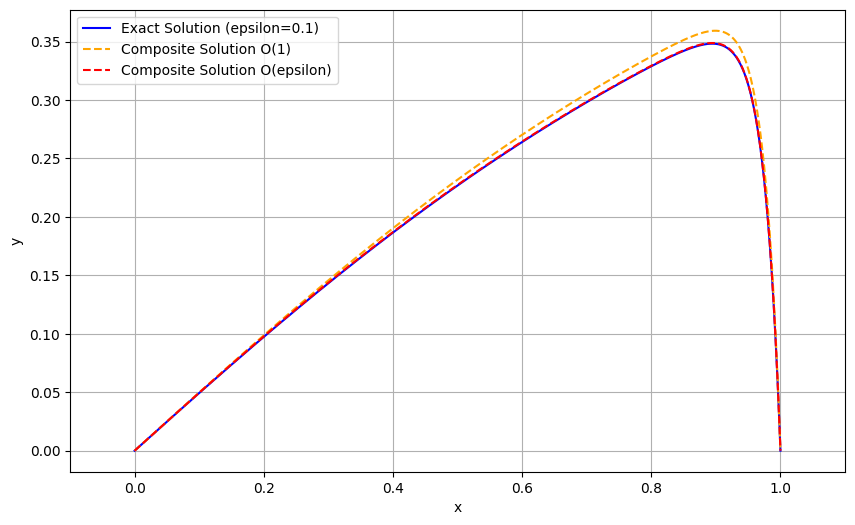

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x_eval, y_exact(x_eval, epsilon1), label='Exact Solution (epsilon=0.1)', color='blue', linestyle='-')
plt.plot(x_eval, y_composite_0(x_eval, epsilon=epsilon1), label='Composite Solution O(1)', color='orange', linestyle='--')
plt.plot(x_eval, y_composite_1(x_eval, epsilon=epsilon1), label='Composite Solution O(epsilon)', color='red', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-0.1, 1.1)
plt.xlim(0, 0.40)
plt.legend()
plt.grid()
plt.savefig("images/various-order.pdf")
plt.show()